In [ ]:
!pip install datasets sentencepiece sacrebleu rouge-score torch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 6.7 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=d34948495e7d6144cf0dbd27fb9096dcd68d9e238b880b4642c094f4bd61e034
  Stored in directory: /root/.cache/pip/wheels/44/af/da/5ffc433e2786f0b1a9c6f458d5fb8f611d8eb332387f18698f
Successfully built rouge-score


In [ ]:
from datasets import load_dataset

ds = load_dataset("uqa/UQA")
print(ds)

ex = ds["train"][0]
print(ex.keys())
print(ex["question"])
print(ex["answer"])
print(ex["answer_start"])
print(ex["is_impossible"])

n_total = len(ds["train"])
n_ans = sum(not imp for imp in ds["train"]["is_impossible"])
print(f"train rows: {n_total}, answerable: {n_ans}")

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 124745
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 16824
    })
})
dict_keys(['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'])
بیونس نے کب مقبولیت حاصل کرنا شروع کی؟
1990 کی دہائی کے آخر میں
273
False
train rows: 124745, answerable: 83018


In [ ]:
import csv

ANS_OPEN, ANS_CLOSE = "<ans>", "</ans>"
SENT_DELIMS = "\u06D4\u061F!"

def split_sentences(text):
    start = 0
    for i, ch in enumerate(text):
        if ch in SENT_DELIMS:
            yield start, i + 1, text[start:i + 1]
            start = i + 1
    if start < len(text):
        yield start, len(text), text[start:]

def make_pair(example, max_src=60, max_tgt=25):
    if example["is_impossible"]:          # unanswerable -> skip
        return None
    a_start = example["answer_start"]
    a_text = example["answer"]
    if a_start < 0 or not a_text:         # safety check
        return None
    context = example["context"]

    for s, e, sent in split_sentences(context):
        if s <= a_start < e:
            rel = a_start - s
            if sent[rel:rel + len(a_text)] != a_text:
                return None
            src = (sent[:rel] + " " + ANS_OPEN + " " + a_text + " "
                   + ANS_CLOSE + " " + sent[rel + len(a_text):]).strip()
            src = " ".join(src.split())
            tgt = " ".join(example["question"].split())
            if len(src.split()) > max_src or len(tgt.split()) > max_tgt:
                return None
            return src, tgt
    return None

def build_split(split, out_path):
    pairs = [p for p in map(make_pair, split) if p is not None]
    with open(out_path, "w", encoding="utf-8", newline="") as f:
        w = csv.writer(f, delimiter="\t", quoting=csv.QUOTE_NONE, escapechar="\\")
        w.writerows(pairs)
    print(f"{out_path}: {len(pairs)} pairs")
    return pairs

train_pairs = build_split(ds["train"], "train.tsv")
valid_pairs = build_split(ds["validation"], "valid.tsv")

train.tsv: 75067 pairs
valid.tsv: 10018 pairs


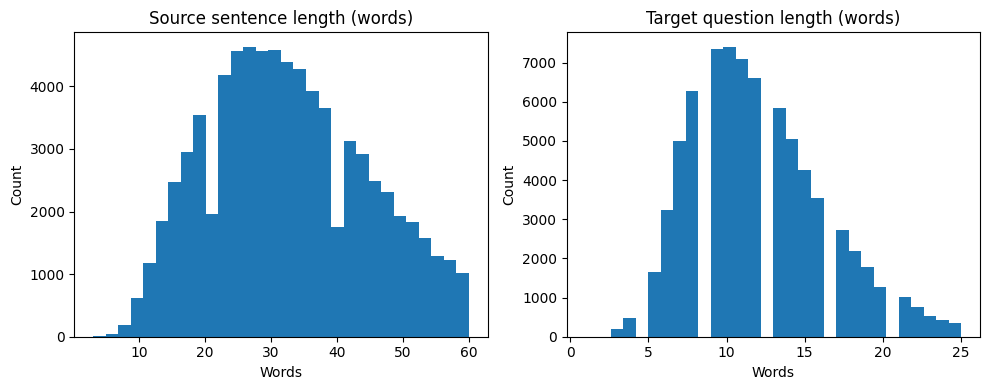

In [ ]:
import matplotlib.pyplot as plt

src_lens = [len(src.split()) for src, tgt in train_pairs]
tgt_lens = [len(tgt.split()) for src, tgt in train_pairs]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(src_lens, bins=30)
axes[0].set_title("Source sentence length (words)")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Count")

axes[1].hist(tgt_lens, bins=30)
axes[1].set_title("Target question length (words)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("length_histograms.png")
plt.show()

In [ ]:
print(f"Train raw rows: {n_total}")
print(f"Train answerable rows: {n_ans}")
print(f"Train pairs after filtering: {len(train_pairs)}")
print(f"Validation pairs after filtering: {len(valid_pairs)}")
print(f"Mean source length: {sum(src_lens)/len(src_lens):.1f} words")
print(f"Mean target length: {sum(tgt_lens)/len(tgt_lens):.1f} words")

Train raw rows: 124745
Train answerable rows: 83018
Train pairs after filtering: 75067
Validation pairs after filtering: 10018
Mean source length: 32.6 words
Mean target length: 11.9 words


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/drive/MyDrive/genai_project
!cp train.tsv valid.tsv length_histograms.png ur_sp.model ur_sp.vocab /content/drive/MyDrive/genai_project/

Mounted at /content/drive
cp: cannot stat 'ur_sp.model': No such file or directory
cp: cannot stat 'ur_sp.vocab': No such file or directory
